In [1]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import fitsio
import healpy
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import astropy.units as u
import astropy.constants as const
import astropy.io.ascii

In [2]:
fcomplete0_LRG = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock0/LRG_complete_clustering.dat.fits"
fcomplete0_ELG = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/mock0/ELG_LOP_complete_clustering.dat.fits"
fforFA0 = "/global/cfs/cdirs/desi/survey/catalogs/Y1/mocks/SecondGenMocks/AbacusSummit_v4_2/forFA0.fits"

sp1 = Table(fitsio.read(fcomplete0_LRG))
sp2 = Table(fitsio.read(fcomplete0_ELG))
sp3 = Table(fitsio.read(fforFA0))

In [3]:
#apply cuts: redshift cut 0.75 < z < 1, 
complete0LRG = sp1[(sp1['Z'] < 1)&(sp1['Z'] > 0.75)&(sp1['ZWARN'] == 0)]
complete0ELG = sp2[(sp2['Z'] < 1)&(sp2['Z'] > 0.75)&(sp2['ZWARN'] == 0)]
forFA0LRG = sp3[(sp3['RSDZ'] < 1)&(sp3['RSDZ'] > 0.75)&(sp3['ZWARN'] == 0)&(sp3["DESI_TARGET"]&0x1==0x1)]
forFA0ELG = sp3[(sp3['RSDZ'] < 1)&(sp3['RSDZ'] > 0.75)&(sp3['ZWARN'] == 0)&(sp3["DESI_TARGET"]&0x2==0x2)]

In [6]:
complete0LRG[:5]

LOCATION,FIBER,TARGETID,RA,DEC,Z,PRIORITY_INIT,PRIORITY,DESI_TARGET,BRICKID,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,ZWARN,COLLISION,TILEID,lrg_mask,PHOTSYS,WEIGHT_SYS,WEIGHT_COMP,WEIGHT_ZFAIL,WEIGHT,NTILE,NX,WEIGHT_FKP
int64,int64,int64,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int16,int64,bool,int64,uint8,str1,float64,float64,float64,float64,int64,float64,float64
1215,761,22,66.59197,-6.946266,0.9406934,3200,3200,1,290390,3,3,6,0,0,False,5613,0,S,1.0,1.0,1.0,1.0,1,0.000292327348532375,0.25488918979031605
7181,3567,83,169.87204,-3.5408707,0.8570048,3200,3200,1,310890,4,4,5,0,0,False,4408,0,S,1.0,1.0,1.0,1.0,1,0.0004949391224953971,0.1680844244711335
1320,870,88,166.21857,-7.7125626,0.7847342,3200,3200,1,286497,3,3,3,0,0,False,4402,0,S,1.0,1.0,1.0,1.0,1,0.0005534827843051208,0.1530262195144662
8138,4195,119,146.04211,61.191246,0.93375444,3200,3200,1,620978,3,3,4,0,0,False,10135,0,N,1.0,1.0,1.0,1.0,1,0.0003203114191951104,0.23791882740539952
5310,2723,121,219.78456,31.635056,0.8772283,3200,3200,1,505111,2,2,2,0,0,False,2203,0,S,1.0,1.0,1.0,1.0,1,0.0004569377499750288,0.17955328042403962


In [41]:
complete_lrg_cut = complete0LRG[(complete0LRG['RA'] < 141)&(complete0LRG['RA'] > 140)& \
                                (complete0LRG['DEC'] < 1)&(complete0LRG['DEC'] > 0)]
                                
forFA_lrg_cut = forFA0LRG[(forFA0LRG['RA'] < 141)&(forFA0LRG['RA'] > 140)& \
                                (forFA0LRG['DEC'] < 1)&(forFA0LRG['DEC'] > 0)]

In [4]:
#find which galaxies are masked by comparing TARGETID
'''eliminatedLRG = compare_tables(forFA0LRG, complete0LRG)
eliminatedELG = compare_tables(forFA0ELG, complete0ELG)'''

'eliminatedLRG = compare_tables(forFA0LRG, complete0LRG)\neliminatedELG = compare_tables(forFA0ELG, complete0ELG)'

In [5]:
def compare_tables(table, tablemasked):
    eliminated = table[:1] #storing all the eliminated galaxies
    table.sort('TARGETID')
    tablemasked.sort('TARGETID')
    j = 0
    for i in range(len(tablemasked)):
        if table['TARGETID'][j] > tablemasked['TARGETID'][i]: continue
        #since masked table skips some targets, we expect masked id > original id. if this is not the case, skip
        #till they're equal.
        while table['TARGETID'][j] < tablemasked['TARGETID'][i]:
            eliminated.add_row(table[j])
            j+=1
            '''print("Mismatch, incrementing unmasked table")
            print(table['TARGETID'][j])
            print(tablemasked['TARGETID'][i])'''
        j+=1
        if i%100000 == 0: print("galaxy " +str(i))
    return eliminated   

'''def checkID(ID, idlist):
    if ID in idlist:
        return True
    else:
        return false'''

'def checkID(ID, idlist):\n    if ID in idlist:\n        return True\n    else:\n        return false'

In [ ]:
targetslrg = complete0LRG['TARGETID']
targetselg = complete0ELG['TARGETID']

eliminatedELG = forFA0ELG[[not(forFA0ELG['TARGETID'][i] in targetselg) for i in range(len(forFA0ELG))]]
eliminatedLRG = forFA0LRG[[not(forFA0LRG['TARGETID'][i] in targetslrg) for i in range(len(forFA0LRG))]]

In [ ]:
astropy.io.ascii.write(eliminatedLRG, 'datafiles/eliminatedLRG.csv', overwrite=True,format='csv')
astropy.io.ascii.write(eliminatedELG, 'datafiles/eliminatedELG.csv', overwrite=True,format='csv')

In [8]:
#different technique
def raDecToUnitSphere(a, d):
    a = a*np.pi/180
    d = d*np.pi/180
    x = np.cos(a)*np.cos(d)
    y = np.sin(a)*np.cos(d)
    z = np.sin(d)
    return [np.array([x[i],y[i],z[i],1]) for i in range(len(a))]
def raDecToCartesian(a, d, r):
    return [dist*xyzd for dist, xyzd in zip(r, raDecToUnitSphere(a,d))]

In [10]:
complete0LRG['d'] = cosmo.comoving_distance(complete0LRG['Z'])/u.Mpc #more convenient to have unitless calculations
complete0ELG['d'] = cosmo.comoving_distance(complete0ELG['Z'])/u.Mpc
complete0LRG['xyzd'] = raDecToCartesian(complete0LRG['RA'],complete0LRG['DEC'],complete0LRG['d'])
complete0ELG['xyzd'] = raDecToCartesian(complete0ELG['RA'],complete0ELG['DEC'],complete0ELG['d'])

forFA0LRG['d'] = cosmo.comoving_distance(forFA0LRG['RSDZ'])/u.Mpc #more convenient to have unitless calculations
forFA0ELG['d'] = cosmo.comoving_distance(forFA0ELG['RSDZ'])/u.Mpc
forFA0LRG['xyzd'] = raDecToCartesian(forFA0LRG['RA'],forFA0LRG['DEC'],forFA0LRG['d'])
forFA0ELG['xyzd'] = raDecToCartesian(forFA0ELG['RA'],forFA0ELG['DEC'],forFA0ELG['d'])

In [13]:
elgtree = cKDTree([coord[:3] for coord in complete0ELG['xyzd']])
lrgtree = cKDTree([coord[:3] for coord in complete0LRG['xyzd']])

rsphere = 0.0001 #very small
elgprimarymap = [coord[:3] for coord in forFA0ELG['xyzd']]
lrgprimarymap = [coord[:3] for coord in forFA0LRG['xyzd']]
forFA0ELG['neighbors'] = elgtree.query_ball_point(elgprimarymap, rsphere)
forFA0LRG['neighbors'] = lrgtree.query_ball_point(lrgprimarymap, rsphere)

In [14]:
eliminated_elg = forFA0ELG[[not(forFA0ELG['TARGETID'][i] in \
                               complete0ELG['TARGETID'][forFA0ELG['neighbors'][i]]) for i in range(len(forFA0ELG))]]
eliminated_lrg = forFA0LRG[[not(forFA0LRG['TARGETID'][i] in \
                               complete0LRG['TARGETID'][forFA0LRG['neighbors'][i]]) for i in range(len(forFA0LRG))]]
                           

In [20]:
astropy.io.ascii.write(eliminated_lrg['RA','DEC','RSDZ'], 'datafiles/eliminatedLRG.csv', overwrite=True,format='csv')
astropy.io.ascii.write(eliminated_elg['RA','DEC','RSDZ'], 'datafiles/eliminatedELG.csv', overwrite=True,format='csv')

(0.0, 1.0)

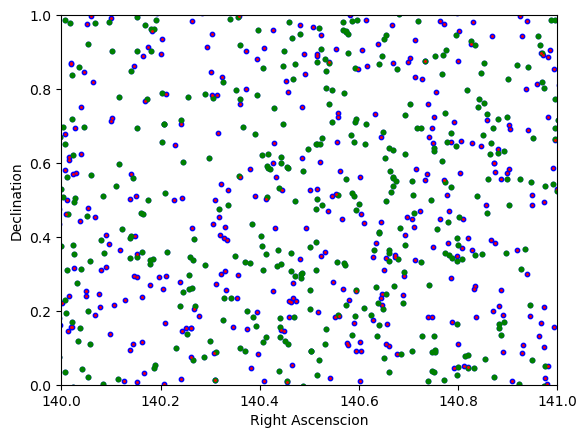

In [37]:
plt.figure()
plt.scatter(forFA0ELG['RA'],forFA0ELG['DEC'],s=10,color='blue')
plt.scatter(complete0ELG['RA'],complete0ELG['DEC'],s=10,color='green')
plt.scatter(eliminated_elg['RA'],eliminated_elg['DEC'],s=1,color='red')
plt.xlabel("Right Ascenscion")
plt.ylabel("Declination")
plt.xlim(140,141)
plt.ylim(0,1)

(-10.0, 25.0)

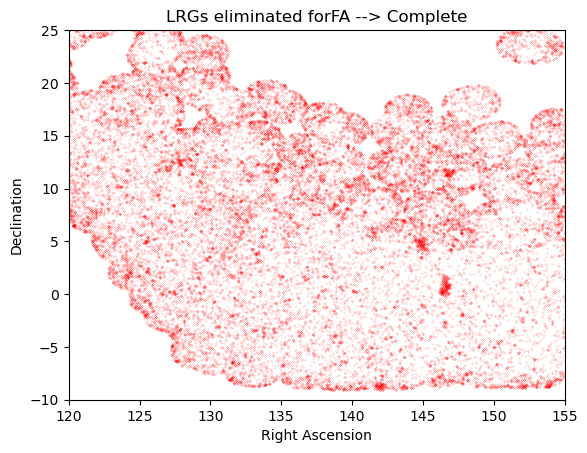

In [40]:
plt.figure()
#plt.scatter(forFA0LRG['RA'],forFA0LRG['DEC'],s=10,color='blue')
#plt.scatter(complete0LRG['RA'],complete0LRG['DEC'],s=10,color='green')
plt.scatter(eliminated_lrg['RA'],eliminated_lrg['DEC'],s=0.01,color='red')
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("LRGs eliminated forFA --> Complete")
plt.xlim(120,155)
plt.ylim(-10,25)

In [51]:
print(len(forFA0LRG))
print(len(complete0LRG))
print(len(forFA0ELG))
print(len(complete0ELG))
print("Proportion of LRGs eliminated: "+str(len(eliminated_lrg)/len(forFA0LRG)))
print("Proportion of ELGs eliminated: "+str(len(eliminated_elg)/len(forFA0ELG)))

2281675
1732792
6989868
3204915
Proportion of LRGs eliminated: 0.24056142965146218
Proportion of ELGs eliminated: 0.5414913414673925


(-10.0, 25.0)

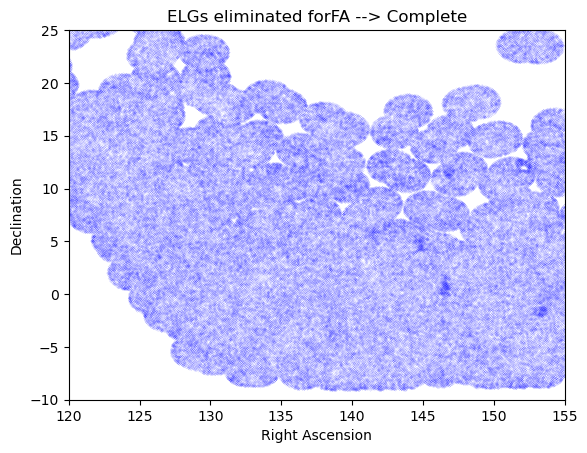

In [70]:
plt.figure()
#plt.scatter(forFA0LRG['RA'],forFA0LRG['DEC'],s=10,color='blue')
#plt.scatter(complete0LRG['RA'],complete0LRG['DEC'],s=10,color='green')
plt.scatter(eliminated_elg['RA'],eliminated_elg['DEC'],s=0.0005,color='blue')
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("ELGs eliminated forFA --> Complete")
plt.xlim(120,155)
plt.ylim(-10,25)

(40.0, 55.0)

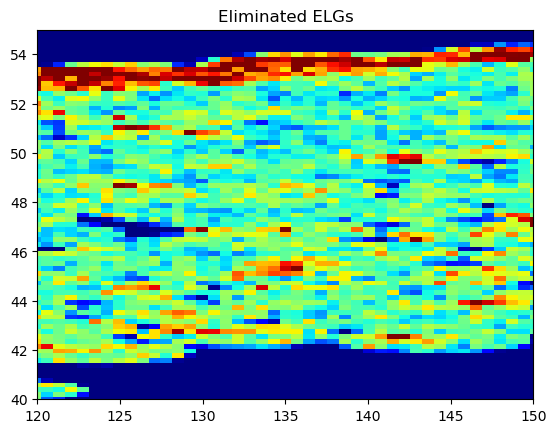

In [64]:
hist2, binsx,binsy = np.histogram2d(eliminated_elg["RA"],eliminated_elg["DEC"], density=True,bins=500)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist2,cmap='jet',vmin=0,vmax=0.0002)
plt.title("Eliminated ELGs")
plt.xlim(120,150)
plt.ylim(40,55)

(40.0, 55.0)

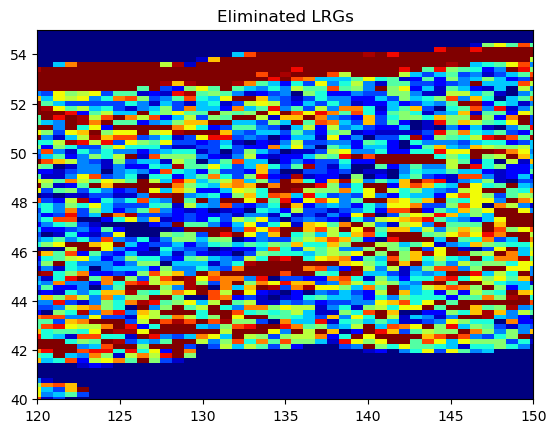

In [65]:
hist1, binsx,binsy = np.histogram2d(eliminated_lrg["RA"],eliminated_lrg["DEC"], density=True,bins=500)
fig, ax = plt.subplots(1)
pc = ax.pcolormesh(binsx,binsy,hist1,cmap='jet',vmin=0,vmax=0.0002)
plt.title("Eliminated LRGs")
plt.xlim(120,150)
plt.ylim(40,55)